In [1]:
import sys
!{sys.executable} -m pip install typing_extensions numpy torch matplotlib gstools

In [2]:
import numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)

torch 2.14.0 | device: cpu


In [3]:
##Loading the data
data = np.load("casr_vancouver_2015_2018.npz")
coarse_stacks = data["coarse_stacks"]     # (N, 1, h, w)
fine_targets  = data["fine_targets"]      # (N, H, W)
COARSE_FACTOR = int(data["coarse_factor"]) if "coarse_factor" in data else None

N, C, h, w = coarse_stacks.shape
_, H, W = fine_targets.shape
print("coarse_stacks:", coarse_stacks.shape)
print("fine_targets :", fine_targets.shape)
print(f"grid: coarse {h}x{w} -> fine {H}x{W}  (factor ~{H//h}x)  | N days = {N}")
assert H != W or True  # rectangle is fine; we handle it below

# handle any NaNs from the crop (ocean edges etc.) by filling with the field mean
if np.isnan(fine_targets).any() or np.isnan(coarse_stacks).any():
    fmean = np.nanmean(fine_targets)
    fine_targets  = np.nan_to_num(fine_targets,  nan=fmean)
    coarse_stacks = np.nan_to_num(coarse_stacks, nan=np.nanmean(coarse_stacks))
    print("filled NaNs with field mean")

coarse_stacks: (1096, 1, 2, 3)
fine_targets : (1096, 6, 9)
grid: coarse 2x3 -> fine 6x9  (factor ~3x)  | N days = 1096


In [4]:
# time-block split: first 75% train, last 25% test (NO shuffle)
n_test = max(1, N // 4)
train_idx = np.arange(0, N - n_test)
test_idx  = np.arange(N - n_test, N)

# normalize with TRAIN stats only (no leakage)
mean = fine_targets[train_idx].mean()
std  = fine_targets[train_idx].std() + 1e-8

def to_tensor(arr): return torch.tensor((arr - mean) / std, dtype=torch.float32)

Xtr = to_tensor(coarse_stacks[train_idx]).to(DEVICE)              # (ntr, 1, h, w)
Ytr = to_tensor(fine_targets[train_idx]).unsqueeze(1).to(DEVICE)  # (ntr, 1, H, W)
Xva = to_tensor(coarse_stacks[test_idx]).to(DEVICE)
Yva = to_tensor(fine_targets[test_idx]).unsqueeze(1).to(DEVICE)
T = C  # channel count, to match the experiment notebook's variable name
print("train:", Xtr.shape, "| test:", Xva.shape)

train: torch.Size([822, 1, 2, 3]) | test: torch.Size([274, 1, 2, 3])


## 2. Method — reuse if present, else define

If you ran the experiment notebook first, `torch_semivariogram` and
`semivariogram_penalty` already exist and this cell leaves them alone. Standalone, it
defines them (identical to that notebook).

In [5]:
if "semivariogram_penalty" not in globals():
    def torch_semivariogram(field, n_bins=10, max_lag=None, n_pairs=4000, gen=None):
        Hh, Ww = field.shape
        if max_lag is None: max_lag = min(Hh, Ww) / 2.0
        if gen is None: gen = torch.Generator(device="cpu").manual_seed(0)
        i1 = torch.randint(0, Hh, (n_pairs,), generator=gen)
        j1 = torch.randint(0, Ww, (n_pairs,), generator=gen)
        i2 = torch.randint(0, Hh, (n_pairs,), generator=gen)
        j2 = torch.randint(0, Ww, (n_pairs,), generator=gen)
        d = torch.sqrt(((i1 - i2).float()**2 + (j1 - j2).float()**2))
        m = (d > 0) & (d <= max_lag)
        d, i1, j1, i2, j2 = d[m], i1[m], j1[m], i2[m], j2[m]
        sq = (field[i1, j1] - field[i2, j2])**2
        edges = torch.linspace(0, max_lag, n_bins + 1)
        centers = 0.5 * (edges[:-1] + edges[1:])
        gamma = field.new_zeros(n_bins)
        for b in range(n_bins):
            sel = (d > edges[b]) & (d <= edges[b + 1])
            if sel.any(): gamma[b] = 0.5 * sq[sel].mean()
        return centers, gamma

    def semivariogram_penalty(pred, target, n_bins=10, max_lag=None, n_pairs=4000):
        B = pred.shape[0]
        total = pred.new_zeros(())
        for b in range(B):
            gen = torch.Generator(device="cpu").manual_seed(b)
            _, gp = torch_semivariogram(pred[b, 0], n_bins, max_lag, n_pairs, gen)
            gen = torch.Generator(device="cpu").manual_seed(b)
            _, gt = torch_semivariogram(target[b, 0], n_bins, max_lag, n_pairs, gen)
            total = total + ((gp - gt)**2).sum()
        return total / B
    print("defined semivariogram_penalty")
else:
    print("reusing semivariogram_penalty from the experiment notebook")

defined semivariogram_penalty


In [6]:
class DoubleConv(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(cout, cout, 3, padding=1), nn.ReLU(inplace=True))
    def forward(self, x): return self.net(x)

class UNetRect(nn.Module):
    """U-Net that upsamples the coarse stack to a rectangular (H, W) fine grid."""
    def __init__(self, in_ch, out_hw, base=32):
        super().__init__()
        self.H, self.W = out_hw
        # pad target up to a multiple of 4 for the two 2x pools
        self.Hp = ((self.H + 3) // 4) * 4
        self.Wp = ((self.W + 3) // 4) * 4
        self.inc  = DoubleConv(in_ch, base)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base, base*2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base*2, base*4))
        self.up2  = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.conv2 = DoubleConv(base*4, base*2)
        self.up1  = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.conv1 = DoubleConv(base*2, base)
        self.outc = nn.Conv2d(base, 1, 1)
    def forward(self, x):
        x = nn.functional.interpolate(x, size=(self.Hp, self.Wp),
                                      mode="bilinear", align_corners=False)
        x1 = self.inc(x); x2 = self.down1(x1); x3 = self.down2(x2)
        u2 = self.conv2(torch.cat([self.up2(x3), x2], dim=1))
        u1 = self.conv1(torch.cat([self.up1(u2), x1], dim=1))
        out = self.outc(u1)
        return out[..., :self.H, :self.W]   # crop padding back to true (H, W)

# shape test
_m = UNetRect(in_ch=T, out_hw=(H, W)).to(DEVICE)
with torch.no_grad():
    _o = _m(Xtr[:1])
print("UNetRect output:", tuple(_o.shape), "(expected (1,1,%d,%d))" % (H, W))

UNetRect output: (1, 1, 6, 9) (expected (1,1,6,9))


## 4. Training loop (rectangle-aware)

In [7]:
def train_model(lam=0.0, epochs=120, lr=1e-3, n_pairs=3000, batch_size=16,
                seed=0, verbose=True):
    torch.manual_seed(seed)
    model = UNetRect(in_ch=T, out_hw=(H, W)).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    hist = {"train": [], "val": [], "mse": [], "semi": []}
    max_lag = min(H, W) / 2
    n_train = Xtr.shape[0]
    for ep in range(epochs):
        model.train(); perm = torch.randperm(n_train)
        eL = eM = eS = 0.0; nb = 0
        for start in range(0, n_train, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = Xtr[idx], Ytr[idx]
            opt.zero_grad(); pred = model(xb)
            loss_mse = mse(pred, yb)
            if lam > 0:
                loss_semi = semivariogram_penalty(pred, yb, n_pairs=n_pairs, max_lag=max_lag)
                loss = loss_mse + lam * loss_semi
            else:
                loss_semi = torch.tensor(0.0); loss = loss_mse
            loss.backward(); opt.step()
            eL += loss.item(); eM += loss_mse.item(); eS += float(loss_semi); nb += 1
        model.eval()
        with torch.no_grad():
            vloss = mse(model(Xva), Yva).item()
        for k, v in [("train", eL/nb), ("val", vloss), ("mse", eM/nb), ("semi", eS/nb)]:
            hist[k].append(v)
        if verbose and (ep % 20 == 0 or ep == epochs-1):
            print(f"  epoch {ep:3d}  train {eL/nb:.4f}  val {vloss:.4f}  semi {eS/nb:.4f}")
    return model, hist

## 5. Train baseline + a small λ sweep

In [8]:
print("BASELINE (MSE only):")
model_base, hist_base = train_model(lam=0.0, epochs=120)

LAMBDAS = [0.01, 0.1, 1.0]      # start small; expand once it runs
models, hists = {}, {}
for L in LAMBDAS:
    print(f"REGULARIZED (lam={L}):")
    models[L], hists[L] = train_model(lam=L, epochs=120)

BASELINE (MSE only):
  epoch   0  train 0.2100  val 0.0359  semi 0.0000
  epoch  20  train 0.0067  val 0.0079  semi 0.0000
  epoch  40  train 0.0060  val 0.0070  semi 0.0000
  epoch  60  train 0.0055  val 0.0073  semi 0.0000
  epoch  80  train 0.0060  val 0.0074  semi 0.0000
  epoch 100  train 0.0042  val 0.0083  semi 0.0000
  epoch 119  train 0.0036  val 0.0078  semi 0.0000
REGULARIZED (lam=0.01):


/var/folders/l7/n6_49wq50y5chmy25lb24n3m0000gn/T/ipykernel_36906/1110653411.py:24: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:821.)
  eL += loss.item(); eM += loss_mse.item(); eS += float(loss_semi); nb += 1


  epoch   0  train 0.2101  val 0.0359  semi 0.0086
  epoch  20  train 0.0067  val 0.0086  semi 0.0008
  epoch  40  train 0.0061  val 0.0071  semi 0.0007
  epoch  60  train 0.0053  val 0.0074  semi 0.0006
  epoch  80  train 0.0054  val 0.0077  semi 0.0005
  epoch 100  train 0.0038  val 0.0078  semi 0.0003
  epoch 119  train 0.0063  val 0.0087  semi 0.0005
REGULARIZED (lam=0.1):
  epoch   0  train 0.2110  val 0.0360  semi 0.0085
  epoch  20  train 0.0067  val 0.0078  semi 0.0007
  epoch  40  train 0.0061  val 0.0070  semi 0.0006
  epoch  60  train 0.0056  val 0.0073  semi 0.0006
  epoch  80  train 0.0067  val 0.0082  semi 0.0005
  epoch 100  train 0.0039  val 0.0081  semi 0.0003
  epoch 119  train 0.0034  val 0.0083  semi 0.0003
REGULARIZED (lam=1.0):
  epoch   0  train 0.2197  val 0.0368  semi 0.0084
  epoch  20  train 0.0078  val 0.0081  semi 0.0006
  epoch  40  train 0.0068  val 0.0073  semi 0.0005
  epoch  60  train 0.0060  val 0.0074  semi 0.0004
  epoch  80  train 0.0051  val 0.007

## 6. Evaluation — pointwise + structure

Same metrics as the experiment notebook. "Truth" is the held-out CaSR fine field
(no Matérn params). Variogram via GSTools, rectangle-aware `max_lag`.

In [9]:
try:
    import gstools as gs
    HAVE_GS = True
except Exception:
    HAVE_GS = False
    print("gstools not installed — variogram section will be skipped")

def r2_score(pred, target):
    ss_res = ((pred - target)**2).sum()
    ss_tot = ((target - target.mean())**2).sum()
    return 1 - ss_res / ss_tot

def eval_model(model, name):
    model.eval()
    with torch.no_grad():
        pred = model(Xva).cpu().numpy()[:, 0]
    true = Yva.cpu().numpy()[:, 0]
    mse_v = np.mean((pred-true)**2); rmse_v = np.sqrt(mse_v)
    mae_v = np.mean(np.abs(pred-true)); r2_v = float(r2_score(pred, true))
    print(f"{name:24s}  MSE {mse_v:.4f}  RMSE {rmse_v:.4f}  MAE {mae_v:.4f}  R2 {r2_v:.4f}")
    return dict(mse=mse_v, rmse=rmse_v, mae=mae_v, r2=r2_v)

print("Test metrics (normalized units):")
eval_model(model_base, "baseline (lam=0)")
for L in LAMBDAS:
    eval_model(models[L], f"regularized (lam={L})")

Test metrics (normalized units):
baseline (lam=0)          MSE 0.0078  RMSE 0.0882  MAE 0.0642  R2 0.9913
regularized (lam=0.01)    MSE 0.0087  RMSE 0.0930  MAE 0.0688  R2 0.9903
regularized (lam=0.1)     MSE 0.0083  RMSE 0.0909  MAE 0.0663  R2 0.9907
regularized (lam=1.0)     MSE 0.0080  RMSE 0.0896  MAE 0.0656  R2 0.9910


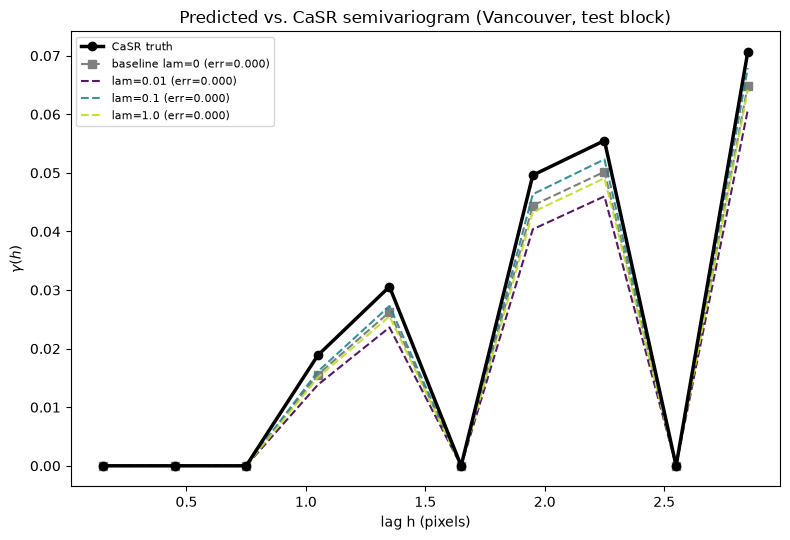

In [10]:
if HAVE_GS:
    def mean_variogram(fields, max_lag=None, n_bins=10):
        Hh, Ww = fields.shape[1], fields.shape[2]
        if max_lag is None: max_lag = min(Hh, Ww) / 2
        x = np.arange(Hh); y = np.arange(Ww)
        gx, gy = np.meshgrid(x, y, indexing="ij")
        coords = (gx.ravel(), gy.ravel())
        edges = np.linspace(0, max_lag, n_bins + 1)
        gams = []
        for f in fields:
            bc, g = gs.vario_estimate(coords, f.ravel(), bin_edges=edges,
                                      sampling_size=4000, sampling_seed=1)
            gams.append(g)
        return bc, np.nanmean(gams, axis=0)

    def predict(model):
        model.eval()
        with torch.no_grad():
            return model(Xva).cpu().numpy()[:, 0]

    true_v = Yva.cpu().numpy()[:, 0]
    bc, g_true = mean_variogram(true_v)
    _,  g_base = mean_variogram(predict(model_base))
    err_base = np.nansum((g_base - g_true)**2)

    plt.figure(figsize=(8, 5.5))
    plt.plot(bc, g_true, "ko-", label="CaSR truth", lw=2.5, zorder=10)
    plt.plot(bc, g_base, "s--", color="tab:grey", lw=1.5,
             label=f"baseline lam=0 (err={err_base:.3f})")
    cmap = plt.cm.viridis(np.linspace(0, 0.9, len(LAMBDAS)))
    for c, L in zip(cmap, LAMBDAS):
        _, g = mean_variogram(predict(models[L]))
        err = np.nansum((g - g_true)**2)
        plt.plot(bc, g, "--", color=c, alpha=0.9, label=f"lam={L} (err={err:.3f})")
    plt.xlabel("lag h (pixels)"); plt.ylabel(r"$\gamma(h)$")
    plt.title("Predicted vs. CaSR semivariogram (Vancouver, test block)")
    plt.legend(fontsize=8); plt.tight_layout(); plt.show()